In [ ]:
"""
Labeled data
Classification is a supervised learning technique the frist 
that we are going to explain in this notebook
the idea is to make predictions on unseen or future intances
with their corresponding class or label

relationship between
                    __class2
input  feature -->  __class1
             ___class2

for example logistic regression
the probability thata a data input belongs to a certain class
between 0 and 1 
with a sigmoid function that is like a S FORM

z = m1 + x1 +m2 *x2 ...
h(z)= 1
     -----
     1 + e'-z
for example if a customer is going to buy a product based in features
like 
web visit and incomes

we assing weights to that fetures
LOG loss --penalices incorrect predictions more effective


Multi classificaton
BINARY CLASIFICATION

"""    

'\nClassification is a supervised learning technique the frist \nthat we are going to explain in this notebook\nthe idea is to make predictions on unseen or future intances\nwith their corresponding class or label\n\nrelationship between\n                    __class2\ninput  feature -->  __class1\n             ___class2\n\n\n'

<function matplotlib.pyplot.show(close=None, block=None)>

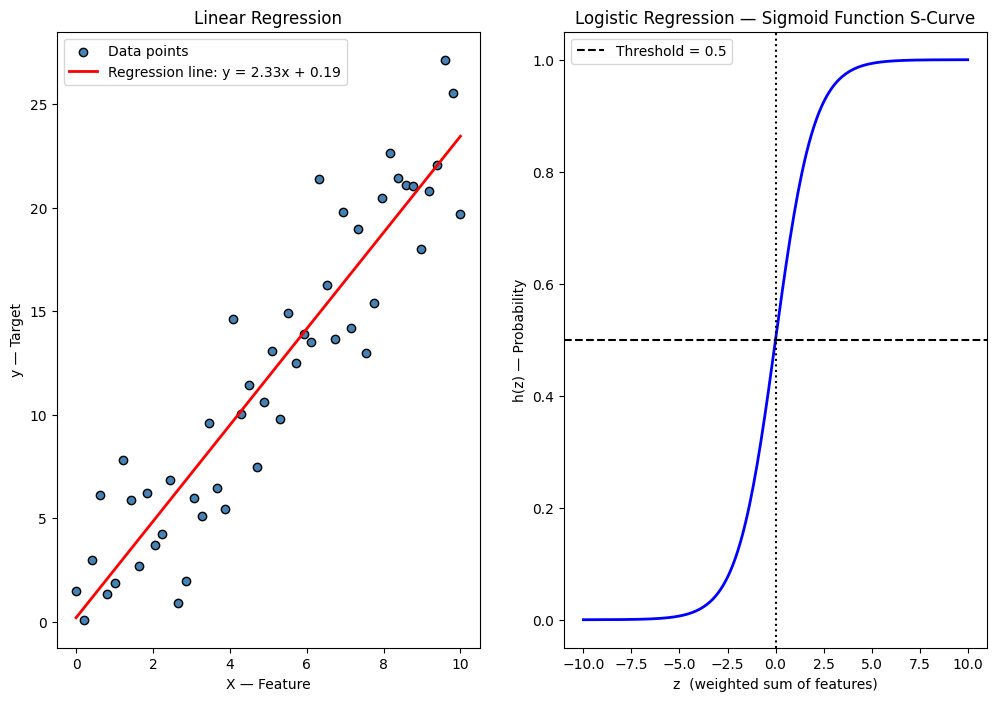

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

"""
sample data for binary class

logistic regression

"""

np.random.seed(64)
class0 = np.random.randn(30, 2) + [1, 1]   # Class 0 cluster
class1 = np.random.randn(30, 2) + [4, 4] 

#sigmoid function
z = np.linspace(-10 ,10,200)
sigmoid = 1 / (1 + np.exp(-z))

"""
sample data for least square errors
slope and regresion line
"""

np.random.seed(42)
X = np.linspace(0, 10, 50)
y = 2.5 * X + np.random.randn(50) * 3   # y = mx + b + noise

m , b = np.polyfit(X,y,1)# slope and intercept
y_pred = m* X+b


fig , (ax1,ax2) = plt.subplots(1,2,figsize=(12,8))
"""
correlation between 2 features 
example x feature = slides og pizza eaten y target 0 weight
also don´t forget correlation coeficcient
"""
ax1.scatter(X, y, color='steelblue', edgecolors='k', label='Data points')
ax1.plot(X, y_pred, color='red', linewidth=2, label=f'Regression line: y = {m:.2f}x + {b:.2f}')

ax1.set_title('Linear Regression')
ax1.set_xlabel('X — Feature')
ax1.set_ylabel('y — Target')
ax1.legend()


ax2.plot(z, sigmoid, color='blue', linewidth=2)
ax2.axhline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
ax2.axvline(0.0, color='black', linestyle=':')
ax2.set_title('Logistic Regression — Sigmoid Function S-Curve')
ax2.set_xlabel('z  (weighted sum of features)')
ax2.set_ylabel('h(z) — Probability')
ax2.legend()


plt.tight_layout
plt.show


In [44]:
"""
Logistic Regression — Why the S-Shape?
=======================================

Linear regression outputs any value: -∞ to +∞
But a probability must stay between 0 and 1.
We need a function that "squashes" any number into that range.

That function is the Sigmoid:

        h(z) =      1
                ---------
                1 + e^(-z)

Where z = m1*x1 + m2*x2 + ... (weighted sum of features)

Why S-shaped?
-------------
- When z is very large  (+∞) → h(z) → 1  (certain it's Class 1)
- When z is very small  (-∞) → h(z) → 0  (certain it's Class 0)
- When z = 0            →      h(z) = 0.5 (decision boundary)

The curve is never flat at the extremes — it always transitions
smoothly, which is what gives it the S form.

Decision rule:
    h(z) >= 0.5  →  predict Class 1
    h(z)  < 0.5  →  predict Class 0

Key idea: logistic regression is still LINEAR under the hood (z is
a line), but the sigmoid wraps it into a probability. That's why
the decision boundary is always a straight line in feature space,
even though the output curve looks like an S.
""" #assited by claude to explain forms

'\nLogistic Regression — Why the S-Shape?\n=======================================\n\nLinear regression outputs any value: -∞ to +∞\nBut a probability must stay between 0 and 1.\nWe need a function that "squashes" any number into that range.\n\nThat function is the Sigmoid:\n\n        h(z) =      1\n                ---------\n                1 + e^(-z)\n\nWhere z = m1*x1 + m2*x2 + ... (weighted sum of features)\n\nWhy S-shaped?\n-------------\n- When z is very large  (+∞) → h(z) → 1  (certain it\'s Class 1)\n- When z is very small  (-∞) → h(z) → 0  (certain it\'s Class 0)\n- When z = 0            →      h(z) = 0.5 (decision boundary)\n\nThe curve is never flat at the extremes — it always transitions\nsmoothly, which is what gives it the S form.\n\nDecision rule:\n    h(z) >= 0.5  →  predict Class 1\n    h(z)  < 0.5  →  predict Class 0\n\nKey idea: logistic regression is still LINEAR under the hood (z is\na line), but the sigmoid wraps it into a probability. That\'s why\nthe decision bo

In [2]:
"""
Our goal is to build a 
classification model that can predict
the species of an Iris flower (discrete value)
 based on its measurements.
"""

'\nOur goal is to build a \nclassification model that can predict\nthe species of an Iris flower (discrete value)\n based on its measurements.\n'

In [6]:
import sklearn
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score

"""
iris data set has 4 fetures ;
sepal lenght 
sepal width
petal lenght
petal width

for three diferrent species of iris

SETOSA VERSICOLOR AND VIRGINICA

using knn

that classifies new data points based 
on the majority vote of
their k nearest neighbors in the training set


we use the balanced accuracy score, 
which is a metric that 
takes into account the imbalance in the number 
of samples across different classes. 
then we can make predicctions with new adata
"""



'\niris data set has 4 fetures ;\nsepal lenght \nsepal width\npetal lenght\npetal width\n\nfor three diferrent species of iris\n\nSETOSA VERSICOLOR AND VIRGINICA\n\nusing knn\n\nthat classifies new data points based \non the majority vote of\ntheir k nearest neighbors in the training set\n\n\nwe use the balanced accuracy score, \nwhich is a metric that \ntakes into account the imbalance in the number \nof samples across different classes. \nthen we can make predicctions with new adata\n'

In [16]:
iris= datasets.load_iris()
X = iris.data
y = iris.target

#split data into the training and testing sets
#part of data to train other to ponderate test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf= KNeighborsClassifier()
clf.fit(X_train, y_train)#splited data

y_p = clf.predict(X_test)# predicctions on the testing set

accuracy = balanced_accuracy_score(y_test,y_p)
print("accuracy level :", accuracy)




accuracy level : 0.9743589743589745


In [ ]:
"""
WHAT WE'VE DONE ??
Why predict on the test set?
Because the model already 
"saw" X_train during training — testing on it would be
 cheating. X_test is unseen data, 
 simulating real future predictions. 

 WE ARE USING THE PARTITIONED DATA

 That's how you measure if the model truly learned.
Where are the features?

In the iris dataset X has 4 features per row, and 
y is the class label:
sepal lengthsepal 
widthpetal lengthpetal
 width→ y 
 (species)5.13.51.40.20 
 (setosa)6.32.85.11.52 (virginica)
"""

Understanding Df

In [41]:
import pandas as pd
from sklearn.datasets import load_iris
"""
visualizing dataset
"""
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
#adding target and classifications
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(df.shape)

print(df.describe())



(150, 6)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [42]:
print(df.head)

<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

In [43]:
"""
REGRESSION
housing example 
"""

'\nREGRESSION\nhousing example \n'

In [37]:
"""
Housing innear regression 

it has information about various housing features
such as 
population 
median income
mediam house prices

we want to predict the median house prices 

that measures the average of
 the squared differences between the predicted
 values and the actual values of a variable.

"""
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error




In [38]:
california_housing = fetch_california_housing()
X = california_housing.data
y = california_housing.target
"""
instrusive pre prosecing

Scaling

splitting

testing sets

"""

model = LinearRegression()
model.fit(X_train,y_train)

# Make predictions on the testing set

y_predl = model.predict(X_test)

mse = mean_squared_error(y_test, y_predl)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.052465334894200875
